In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import StandardScaler, LabelEncoder
from google.colab import files
import io

# Setup for professional visualizations
plt.style.use('seaborn-v0_8')
%matplotlib inline

# File Upload Utility
print("Please upload your 'train.csv' file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\nSuccessfully loaded {filename}")

Please upload your 'train.csv' file:


Saving train.csv to train (3).csv

Successfully loaded train (3).csv


In [23]:
# --- STEP 1: NumPy Warm-Up ---
print("Executing NumPy Exercises...")

# (a) 6x4 matrix of random integers (0-100)
scores_np = np.random.randint(0, 101, (6, 4))
print(f"Original Scores:\n{scores_np}")

# (b) Normalize columns to [0,1] using broadcasting only
# Formula: (x - min) / (max - min)
norm_scores = (scores_np - scores_np.min(axis=0)) / (scores_np.max(axis=0) - scores_np.min(axis=0))
print(f"\nNormalized Scores (Broadcasting):\n{norm_scores.round(3)}")

# (c) Boolean mask for students averaging >= 0.60
avg_scores = norm_scores.mean(axis=1)
pass_mask = avg_scores >= 0.60
print(f"\nPassing Students Data:\n{norm_scores[pass_mask]}")

# (d) np.where to replace scores below 40 with column mean
col_means = scores_np.mean(axis=0)
cleaned_scores = np.where(scores_np < 40, col_means, scores_np)
print(f"\nScores after replacing < 40 with means:\n{cleaned_scores}")

# (e) Dot product for weighted scoring system
weights = np.array([0.4, 0.3, 0.2, 0.1]) # Random weights
weighted_totals = norm_scores @ weights
print(f"\nWeighted Totals:\n{weighted_totals.round(3)}")

Executing NumPy Exercises...
Original Scores:
[[ 61  61  46  61]
 [ 50  54  63   2]
 [100  50   6  20]
 [ 72  38  17   3]
 [ 88  59  13   8]
 [ 89  52   1  83]]

Normalized Scores (Broadcasting):
[[0.22  1.    0.726 0.728]
 [0.    0.696 1.    0.   ]
 [1.    0.522 0.081 0.222]
 [0.44  0.    0.258 0.012]
 [0.76  0.913 0.194 0.074]
 [0.78  0.609 0.    1.   ]]

Passing Students Data:
[[0.22       1.         0.72580645 0.72839506]]

Scores after replacing < 40 with means:
[[ 61.          61.          46.          61.        ]
 [ 50.          54.          63.          29.5       ]
 [100.          50.          24.33333333  29.5       ]
 [ 72.          52.33333333  24.33333333  29.5       ]
 [ 88.          59.          24.33333333  29.5       ]
 [ 89.          52.          24.33333333  83.        ]]

Weighted Totals:
[0.606 0.409 0.595 0.229 0.624 0.595]


--- Dataset Inspection ---
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Numerical Columns: 7
Categorical Columns: 5
Total Missing Cells: 866

--- Missing Value Visualization ---


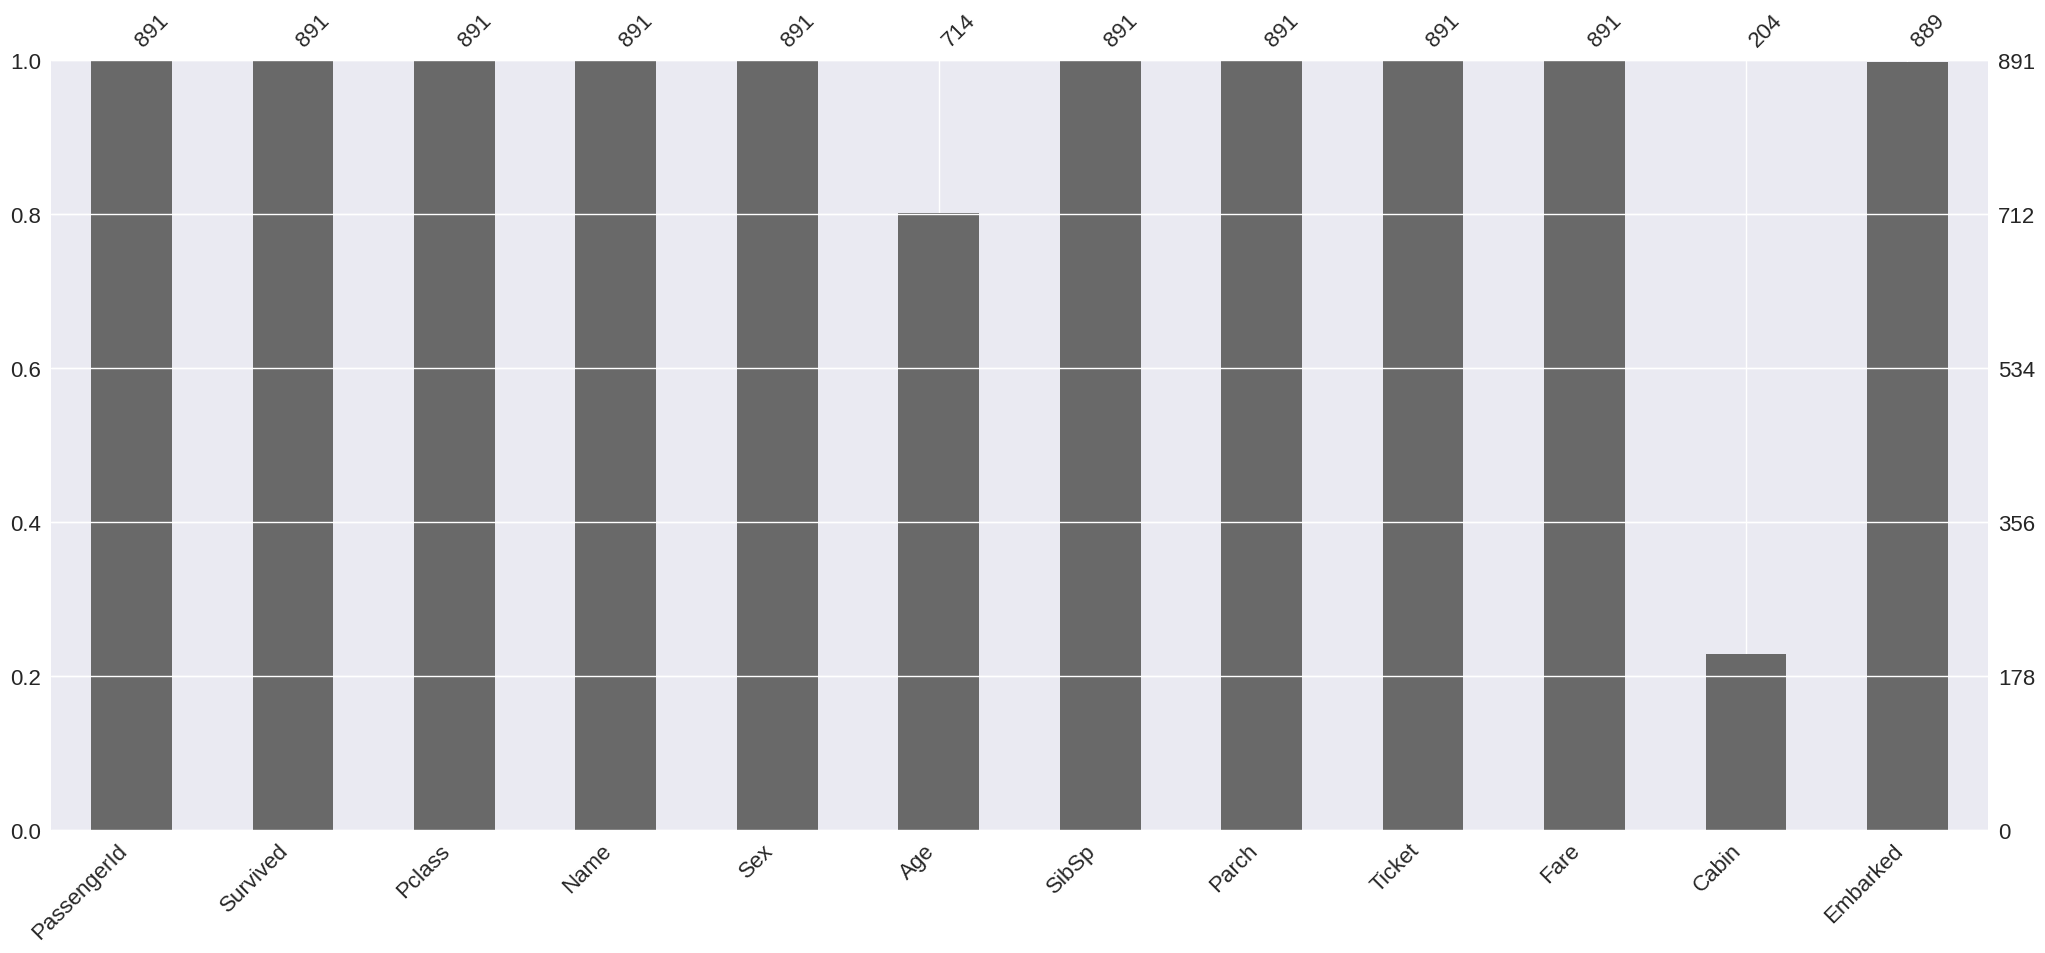


Updated Data Types:
Survived    category
Pclass      category
dtype: object


In [24]:
# --- STEP 2: Load & Initial Inspection ---
print("--- Dataset Inspection ---")
print(f"Shape: {df.shape}")
display(df.head(10))
df.info()

# Counts
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print(f"\nNumerical Columns: {len(num_cols)}")
print(f"Categorical Columns: {len(cat_cols)}")
print(f"Total Missing Cells: {df.isnull().sum().sum()}")

# --- STEP 3: Missing Value Deep Analysis ---
print("\n--- Missing Value Visualization ---")
plt.figure(figsize=(10, 4))
msno.bar(df)
plt.show()

# --- STEP 4: Data Type Audit ---
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
print("\nUpdated Data Types:")
print(df.dtypes[['Survived', 'Pclass']])

In [25]:
# --- STEP 5: Handle Missing Values ---
# Group-level imputation for Age (superior to global mean)
df['Age'] = df.groupby(['Pclass', 'Sex'], observed=False)['Age'].transform(lambda x: x.fillna(x.median()))

# Mode for Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Binary feature for Cabin
df['has_cabin'] = df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
# Keep original for deck extraction later, then drop
original_cabin = df['Cabin'].copy()
df.drop('Cabin', axis=1, inplace=True)

# --- STEP 6: Outlier Detection & Treatment ---
def handle_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    return lower_fence, upper_fence

# Cap Fare at 99th percentile (Winsorization)
fare_99 = df['Fare'].quantile(0.99)
df['Fare'] = np.where(df['Fare'] > 300, fare_99, df['Fare'])
print("Fare outliers capped at 99th percentile.")

Fare outliers capped at 99th percentile.


In [26]:
# --- STEP 7: 7 New Columns ---
df['family_size'] = df['SibSp'] + df['Parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)
df['fare_per_person'] = df['Fare'] / df['family_size']

# Title Extraction
df['title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['title'] = df['title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['title'] = df['title'].replace('Mlle', 'Miss').replace('Ms', 'Miss').replace('Mme', 'Mrs')

# Age & Fare Binning
df['age_group'] = pd.cut(df['Age'], bins=[0, 12, 18, 60, 120], labels=['Child', 'Teen', 'Adult', 'Senior'])
df['fare_bin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'VHigh'])

# Deck Extraction
df['deck'] = original_cabin.str[0].fillna('U') # U for Unknown

# --- STEP 8: Encoding ---
# Label Encode Sex
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['Sex']) # male=1, female=0 usually

# One-Hot Encode Embarked & Title
df = pd.get_dummies(df, columns=['Embarked', 'title'], drop_first=True)

# Ordinal Encode
age_mapping = {'Child': 0, 'Teen': 1, 'Adult': 2, 'Senior': 3}
df['age_group_encoded'] = df['age_group'].map(age_mapping)

# --- STEP 9: Feature Scaling ---
scaler = StandardScaler()
scale_cols = ['Age', 'Fare', 'fare_per_person', 'family_size']
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Save Cleaned Data
df.to_csv('titanic_cleaned.csv', index=False)
print("Cleaned dataset saved as 'titanic_cleaned.csv'.")

Cleaned dataset saved as 'titanic_cleaned.csv'.


<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_13558/1191080661.py:7: SyntaxWarning: invalid escape sequence '\.'
  df['title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


/tmp/ipykernel_13558/1807021596.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=factor, y='Survived', data=df, errorbar=None, palette='viridis')
/tmp/ipykernel_13558/1807021596.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=factor, y='Survived', data=df, errorbar=None, palette='viridis')
/tmp/ipykernel_13558/1807021596.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=factor, y='Survived', data=df, errorbar=None, palette='viridis')
/tmp/ipykernel_13558/1807021596.py:6: FutureWarning: 

Passing `palette` without assigning `hu

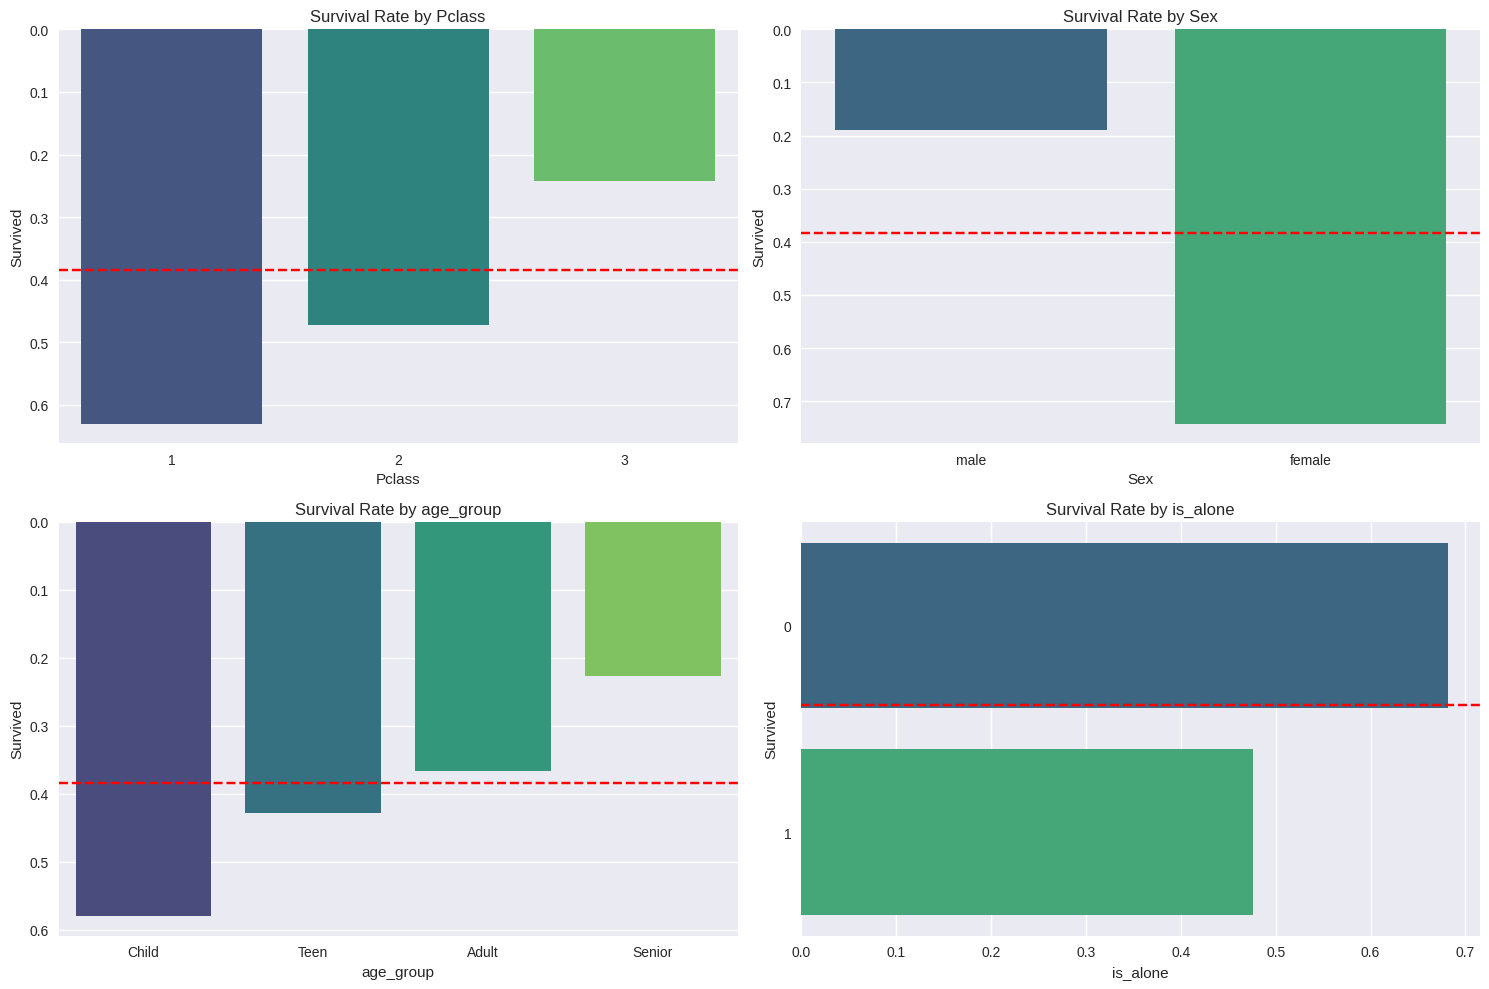


Custom Aggregation Results (Fare > 50% and Age IQR):



Fare                           Age            Survived      
        mean median   std <lambda_0>  mean <lambda_0>     mean count
Pclass                                                              
1       1.14   0.67  1.46        0.0  0.69       1.37     0.63   216
2      -0.25  -0.40  0.31        0.0  0.06       0.98     0.47   184
3      -0.41  -0.54  0.27        0.0 -0.32       0.66     0.24   491

/tmp/ipykernel_13558/1807021596.py:29: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot1 = pivot_df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')


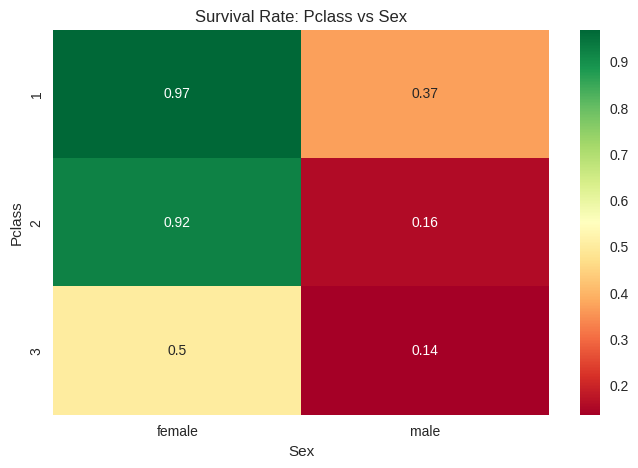

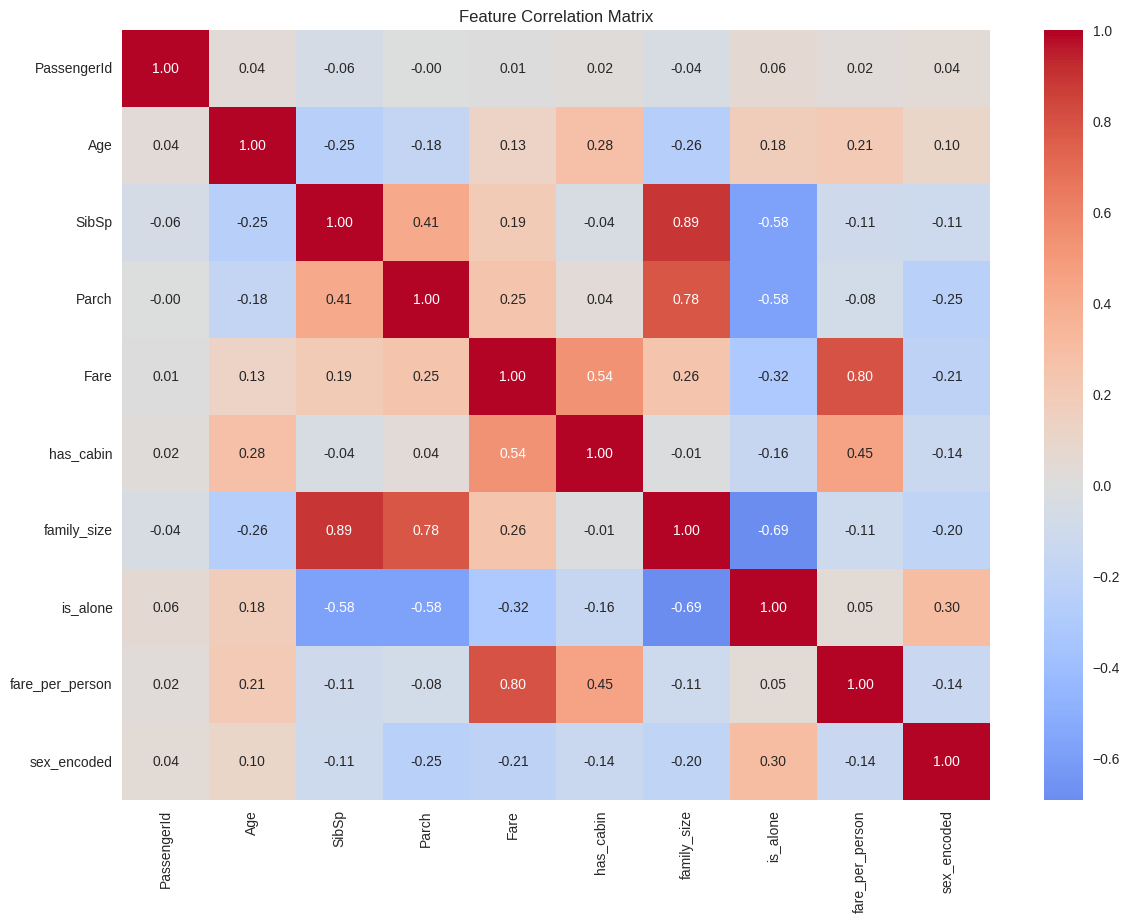

In [29]:
# --- STEP 10: Survival Analysis ---
factors = ['Pclass', 'Sex', 'age_group', 'is_alone']
plt.figure(figsize=(15, 10))
for i, factor in enumerate(factors, 1):
    plt.subplot(2, 2, i)
    sns.barplot(x=factor, y='Survived', data=df, errorbar=None, palette='viridis')
    plt.axhline(0.384, color='red', linestyle='--', label='Overall Rate')
    plt.title(f'Survival Rate by {factor}')

plt.tight_layout()
plt.show()

# --- STEP 11: Advanced Aggregation ---
# Temporarily convert 'Survived' to int for mean aggregation
agg_df = df.copy()
agg_df['Survived'] = agg_df['Survived'].astype(int)

agg_df = agg_df.groupby('Pclass', observed=False).agg({
    'Fare': ['mean', 'median', 'std', lambda x: (x > 50).mean() * 100],
    'Age': ['mean', lambda x: x.quantile(0.75) - x.quantile(0.25)],
    'Survived': ['mean', 'count']
})
print("\nCustom Aggregation Results (Fare > 50% and Age IQR):\n")
display(agg_df.round(2))

# --- STEP 12: Pivot Table Heatmaps ---
pivot_df = df.copy() # Create a copy to avoid modifying the original DataFrame 'df'
pivot_df['Survived'] = pivot_df['Survived'].astype(int) # Convert 'Survived' to int
pivot1 = pivot_df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot1, annot=True, cmap='RdYlGn')
plt.title("Survival Rate: Pclass vs Sex")
plt.show()

# --- STEP 13: Correlation Analysis ---
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

--- NumPy Only Calculations ---
Column Means: [ 2.15315981e-16  3.38923303e-17 -2.39239978e-17  6.47586981e-01]
Z-score Check (Mean should be ~0): [ 0.  0. -0. -0.]


/tmp/ipykernel_13558/3552932916.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0, 0], palette='magma')
/tmp/ipykernel_13558/3552932916.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[1, 0], palette='Pastel1')


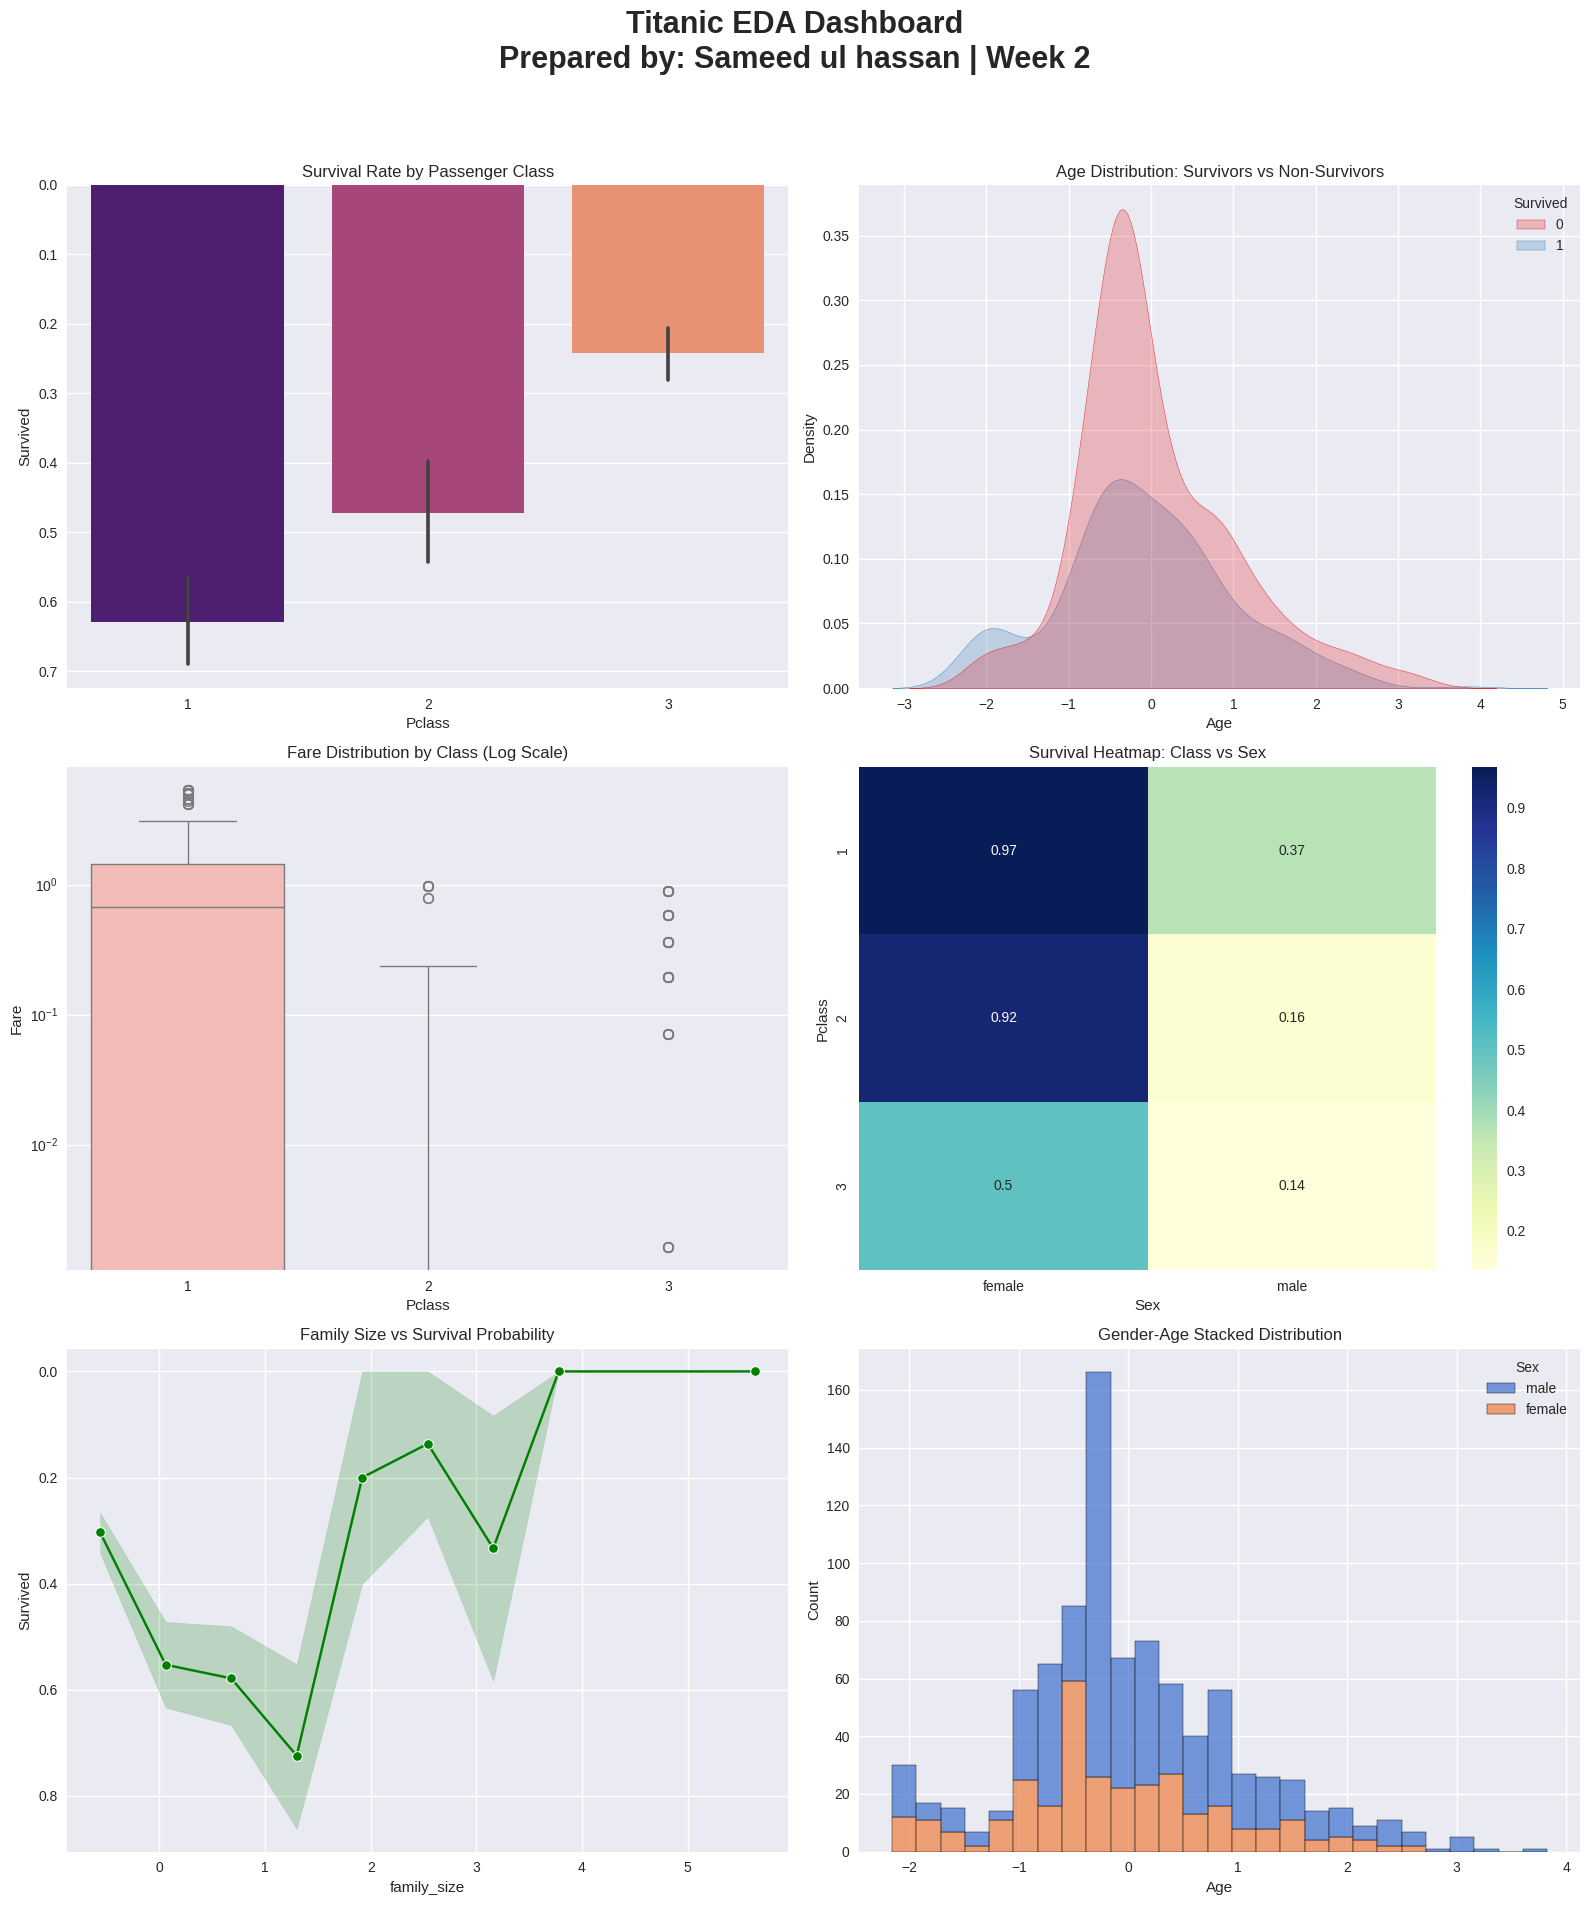


Task Complete. 'titanic_dashboard.png' and 'titanic_cleaned.csv' are ready for submission.


In [32]:
# --- STEP 14: NumPy ONLY Performance Analysis ---
# Extracting numerical features
np_data = df[['Age', 'Fare', 'family_size', 'sex_encoded']].values

print("--- NumPy Only Calculations ---")
print(f"Column Means: {np.mean(np_data, axis=0)}")
# Z-score matrix
z_score_np = (np_data - np.mean(np_data, axis=0)) / np.std(np_data, axis=0)
print(f"Z-score Check (Mean should be ~0): {np.mean(z_score_np, axis=0).round(2)}")

# --- STEP 15: Professional 6-Chart Dashboard ---
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
fig.suptitle(f"Titanic EDA Dashboard\nPrepared by: Sameed ul hassan | Week 2", fontsize=22, fontweight='bold')

# 1. Survival by Pclass
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Survival Rate by Passenger Class')

# 2. Age Distribution (KDE)
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Age Distribution: Survivors vs Non-Survivors')

# 3. Fare Boxplot by Pclass
sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[1, 0], palette='Pastel1')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Fare Distribution by Class (Log Scale)')

# 4. Survival Heatmap (Pclass x Sex)
sns.heatmap(pivot1, annot=True, cmap='YlGnBu', ax=axes[1, 1])
axes[1, 1].set_title('Survival Heatmap: Class vs Sex')

# 5. Family Size vs Survival
sns.lineplot(x='family_size', y='Survived', data=df, ax=axes[2, 0], color='green', marker='o')
axes[2, 0].set_title('Family Size vs Survival Probability')

# 6. Title Survival Proportion
# Create a temporary integer Series from 'Survived' for mean calculation
survived_int_series = df['Survived'].astype(int)
title_surv = survived_int_series.groupby(df['title_Mr'], observed=False).mean() # Example title column
sns.histplot(data=df, x='Age', hue='Sex', multiple="stack", ax=axes[2, 1], palette='muted')
axes[2, 1].set_title('Gender-Age Stacked Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('titanic_dashboard.png', dpi=150)
plt.show()

print("\nTask Complete. 'titanic_dashboard.png' and 'titanic_cleaned.csv' are ready for submission.")